#**Tema: Costrucción de un Modelo de Machine Learning Supervisado basado en Angoritmo de Caja Blanca: Maquina de Soporte Vectoreal (SVR) que prediga el precio de las casas en California**

Alumno________

Materia: ____________

Docente: ____________

Periodo: ________

# 1 - Cargar Librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets, linear_model


In [ ]:
from sklearn import datasets, linear_model

# 2 - Cargar los Datos

In [ ]:
# En este ejercicio usaremos un dataset disponible en la librería sklearn
# referente a las caracteristicas y preciosa de las casas en California
ds_california = datasets.fetch_california_housing()

In [ ]:
type(ds_california)

sklearn.utils._bunch.Bunch

In [ ]:
# Considerando que la data de california se encuentra en una estructura de tipo bunch.Bunch 
# se mapea los datos aun a estructura de tipo dataframe de pandas

df_california = pd.DataFrame(ds_california.data, columns=ds_california.feature_names)


In [ ]:
# en caso de que la dataset no este disponible, puede usar el siguiente respaldo en github
# df_california = pd.read_csv('datasets/TALLER_04_Dataset_California_Housing.csv')

In [ ]:
type(df_california)

pandas.core.frame.DataFrame

In [ ]:
df_california.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [ ]:
df_california['PRICE'] = boston.target

In [ ]:
df_california.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'PRICE'],
      dtype='object')

In [ ]:
#boston2 = datasets.fetch_openml(name='boston', version=1, as_frame=True)
#print("Boston dataset loaded successfully.")

In [ ]:
#type(boston2)

In [ ]:
df_california.shape

(20640, 9)

# 3 - Explorar los datos

In [ ]:
df_california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


**MedInc:** Ingreso medio de los hogares en la zona.

**HouseAge:** Edad promedio de las casas en la zona.

**AveRooms**: Número promedio de habitaciones por vivienda.

**AveBedrms:** Número promedio de dormitorios por vivienda.

**Population:** Población total en la zona.

**AveOccup**: Número promedio de ocupantes por vivienda.

**Latitude:** Latitud geográfica de la zona.

**Longitude**: Longitud geográfica de la zona.

**PRICE**: Precio promedio de a vivienda.



# 4 - Dar tramiento a los datos crudos para obtener una Vista Minable

In [ ]:
# prompt: considera que se requiere realizar la limpieza de los datos del dataframe df_california, genera los comandos necesarios, evalua posibles datos perdiodos, presenta histograma de freecuencia y diagramas de cajas para detectar posible outliners

# 5 - Limpieza de datos
# Evaluar posibles datos perdidos
print("Missing values per column:")
print(df_california.isnull().sum())

Missing values per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64


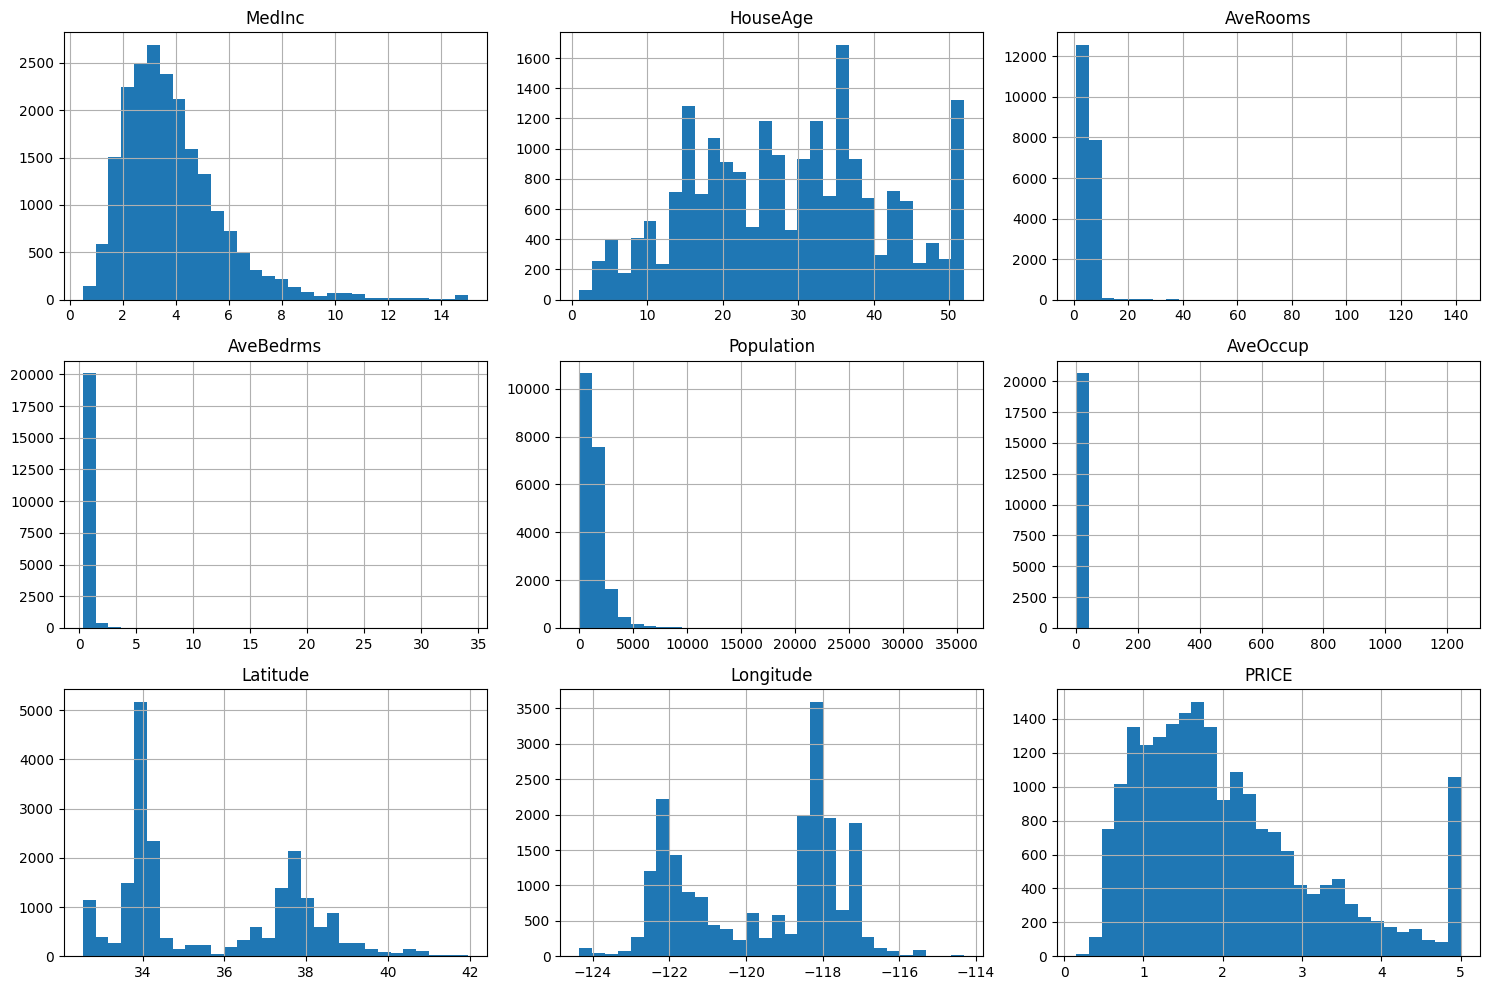

In [ ]:
# Histograma de frecuencia para cada columna para visualizar la distribución
df_california.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

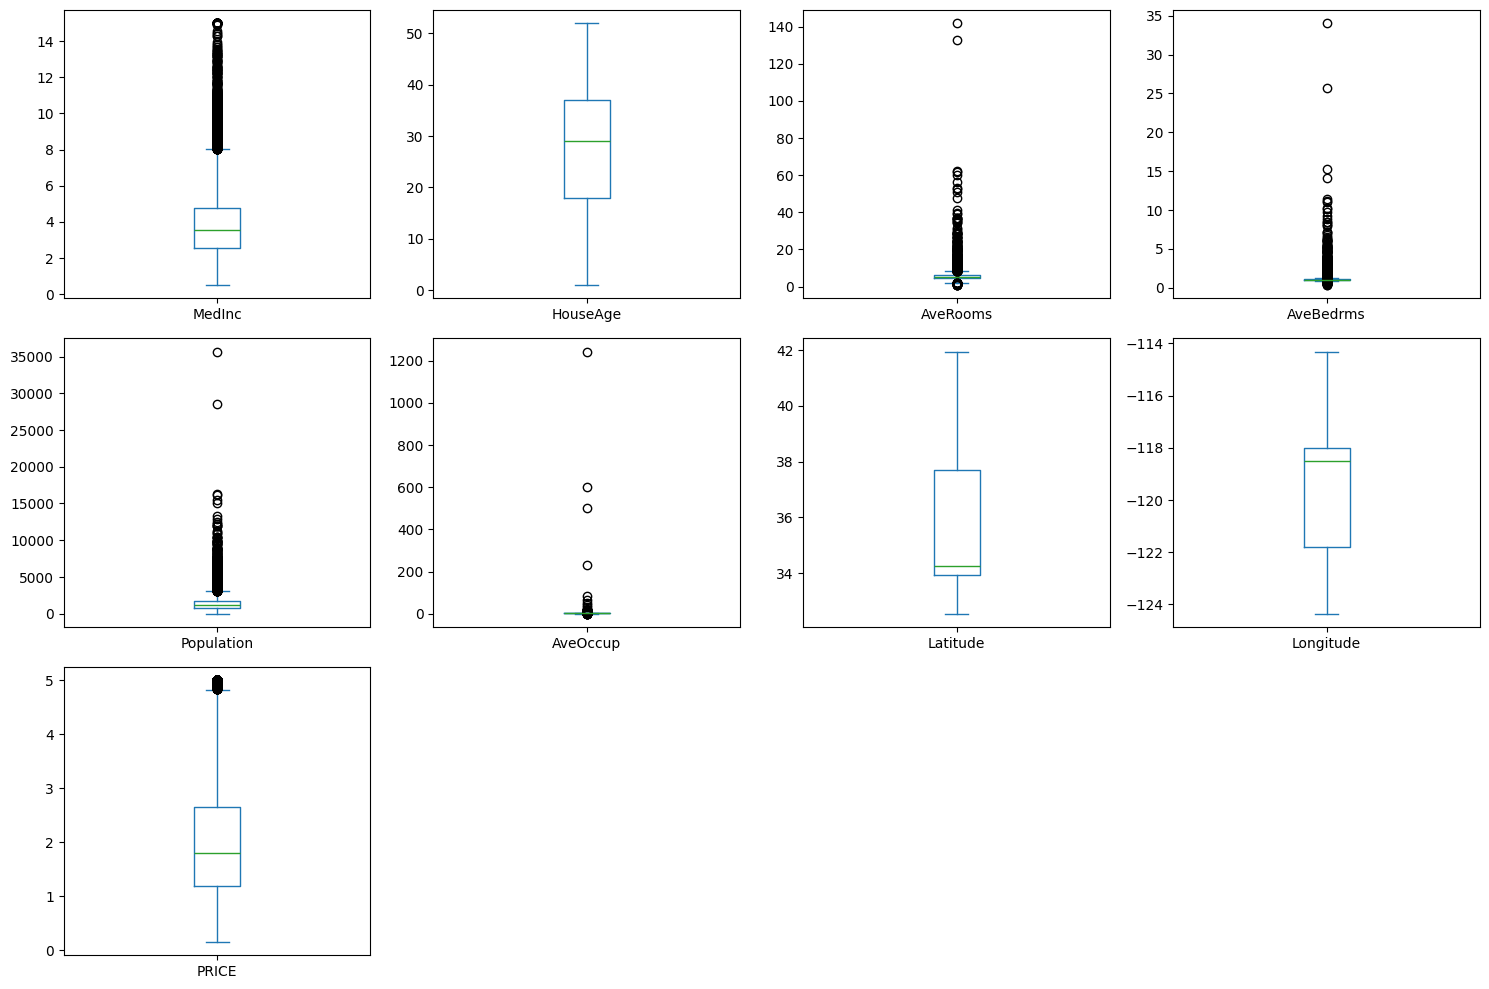

In [ ]:
# Diagramas de cajas para detectar posibles outliers
df_california.plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

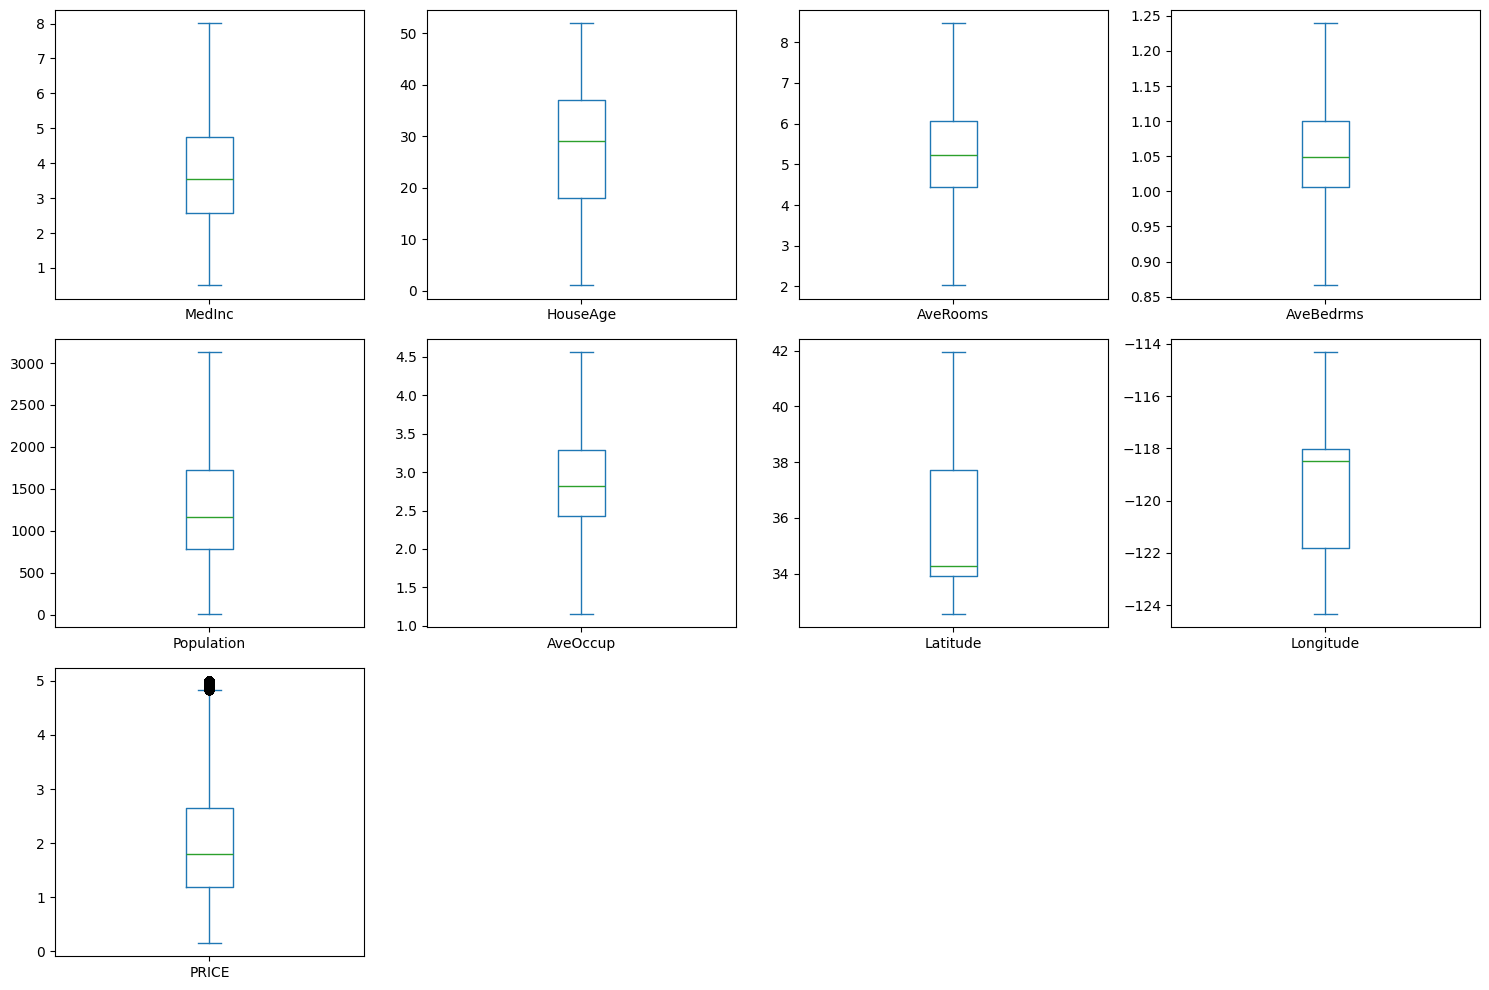

In [ ]:
# prompt: genera el codigo para corregir los outliers superiores e inferiores

# Función para corregir outliers usando el método del rango intercuartílico (IQR)
def correct_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - (1.5 * IQR)
  upper_bound = Q3 + (1.5 * IQR)

  # Reemplazar outliers por los límites (opcional: podrías usar la mediana, etc.)
  df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
  df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
  return df

# Aplicar la corrección de outliers a las columnas numéricas (excluyendo PRICE ya que es el objetivo)
for col in df_california.columns:
  if col != 'PRICE':
    df_california = correct_outliers_iqr(df_california, col)

# Mostrar diagramas de cajas después de la corrección para verificar
df_california.plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()


# 5 - Divir los datos en entrada (Xs) y salida (Y)

In [ ]:
# prompt: separa a price como columna 'Y' y reserva el 70% para entrenmiento y 30% para pruneas

from sklearn.model_selection import train_test_split

X = df_california.drop('PRICE', axis=1)
Y = df_california['PRICE']


# 6 - Dividir los datos en Entrenamiento (train) en Pruebas (test)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (14448, 8)
Shape of X_test: (6192, 8)
Shape of Y_train: (14448,)
Shape of Y_test: (6192,)


# 7 - Crear el Modelo

Modelo basado en Algoritmo de SVR - Maquina de Soporte Vectorea SVR pararesolver problema de Regresión

##Opción 2 - Modelo basado en Algoritmo de Maquina de Soporte Vectoreal

In [ ]:
# prompt: ahorta entrena el modelo con maquina soporte vecteal y mide la calidad con las metricas

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Crear una instancia del modelo SVR
# Puedes experimentar con diferentes kernels
# ('linear', 'poly', 'rbf', 'sigmoid')
# y parámetros como C y gamma para optimizar el rendimiento.

# Aquí usamos un kernel RBF como ejemplo.
modelo1_svr = SVR(kernel='rbf')

# 8 - Entrenar el Modelo

In [ ]:
# Entrenar el modelo con los datos de entrenamiento
modelo1_svr.fit(X_train, Y_train)

# Realizar predicciones en los datos de prueba
Y_pred_svr1 = modelo1_svr.predict(X_test)

# 9 - Evaluar el modelo con métricas de calidad

In [ ]:
# Evaluar la calidad del modelo utilizando métricas

# Error Cuadrático Medio (MSE) para SVR
mse_svr1 = mean_squared_error(Y_test, Y_pred_svr1)
print(f'Error Cuadrático Medio (MSE) con kernel rbf para SVR: {mse_svr1}')

# Coeficiente de Determinación (R^2) para SVR
r2_svr1 = r2_score(Y_test, Y_pred_svr1)
print(f'Coeficiente de Determinación (R^2) con kernel rbf para SVR: {r2_svr1}')

Error Cuadrático Medio (MSE) con kernel rbf para SVR: 1.344312180287012
Coeficiente de Determinación (R^2) con kernel rbf para SVR: -0.02420655360091617


#**Modelo #2 de SVM R - con Kernel Lineal**

In [ ]:
# Aquí usamos un kernel RBF como ejemplo.
modelo2_svr = SVR(kernel='linear', verbose=True)

# Entrenar el modelo con los datos de entrenamiento
# modelo2_svr.fit(X_train, Y_train)

# Realizar predicciones en los datos de prueba
# Y_pred_svr2 = modelo2_svr.predict(X_test)

# Evaluar la calidad del modelo utilizando métricas

# Error Cuadrático Medio (MSE) para SVR
# mse_svr2 = mean_squared_error(Y_test, Y_pred_svr2)
#print(f'MSE con kernel lineal para SVR: {mse_svr2}')

# Coeficiente de Determinación (R^2) para SVR
# r2_svr2 = r2_score(Y_test, Y_pred_svr2)
# print(f'R^2 con kernel lineal para SVR: {r2_svr2}')

#**SVM R - Kernel polinómico de grado 3**

In [ ]:
#------------- SVM con Kernel poly de grado 3 -------------------

# Aquí usamos un kernel RBF como ejemplo.
modelo3_svr = SVR(kernel='poly', degree=3)

# Entrenar el modelo con los datos de entrenamiento
modelo3_svr.fit(X_train, Y_train)

# Realizar predicciones en los datos de prueba
Y_pred_svr3 = modelo3_svr.predict(X_test)

# Evaluar la calidad del modelo utilizando métricas

# Error Cuadrático Medio (MSE) para SVR
mse_svr3 = mean_squared_error(Y_test, Y_pred_svr3)
print(f'MSE con kernel poly grado 3 para SVR: {mse_svr3}')

# Coeficiente de Determinación (R^2) para SVR
r2_svr3 = r2_score(Y_test, Y_pred_svr3)
print(f'R^2 con kernel poly grado 3 para SVR: {r2_svr3}')



#**SVM R - Kernel polinómico de grado 4**

In [ ]:
# Aquí usamos un kernel RBF como ejemplo.
modelo4_svr = SVR(kernel='poly', degree=4)

# Entrenar el modelo con los datos de entrenamiento
modelo4_svr.fit(X_train, Y_train)

# Realizar predicciones en los datos de prueba
Y_pred_svr4 = modelo4_svr.predict(X_test)

# Evaluar la calidad del modelo utilizando métricas

# Error Cuadrático Medio (MSE) para SVR
mse_svr4 = mean_squared_error(Y_test, Y_pred_svr3)
print(f'MSE con kernel poly grado 4 para SVR: {mse_svr4}')

# Coeficiente de Determinación (R^2) para SVR
r2_svr4 = r2_score(Y_test, Y_pred_svr4)
print(f'R^2 con kernel poly grado 4 para SVR: {r2_svr4}')

MSE con kernel poly grado 4 para SVR: 1.3375261392774425
R^2 con kernel poly grado 4 para SVR: 0.007785072923900183


#**SVC R - Kernenel sigmoidal**

In [ ]:
# prompt: ahorta entrena el modelo con maquina soporte vecteal y mide la calidad con las metricas

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

#------------- SVM con Kernel sigmoidal  -------------------

# Aquí usamos un kernel RBF como ejemplo.
modelo5_svr = SVR(kernel='sigmoid')

# Entrenar el modelo con los datos de entrenamiento
modelo5_svr.fit(X_train, Y_train)

# Realizar predicciones en los datos de prueba
Y_pred_svr5 = modelo5_svr.predict(X_test)

# Evaluar la calidad del modelo utilizando métricas

# Error Cuadrático Medio (MSE) para SVR
mse_svr5 = mean_squared_error(Y_test, Y_pred_svr5)
print(f'MSE con kernel sigmoidal ara SVR: {mse_svr5}')

# Coeficiente de Determinación (R^2) para SVR
r2_svr5 = r2_score(Y_test, Y_pred_svr3)
print(f'R^2 con kernel sigmoidal para SVR: {r2_svr5}')

MSE con kernel sigmoidal ara SVR: 188466.88501007727
R^2 con kernel sigmoidal para SVR: -0.01903639463269058


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Árbol de Decisión con profundidad máxima de 5 (poda)
modelo_dt = DecisionTreeRegressor(max_depth=5)
modelo_dt.fit(X_train, Y_train)

# Predicción
Y_pred_dt = modelo_dt.predict(X_test)

# Evaluación
mse_dt = mean_squared_error(Y_test, Y_pred_dt)
r2_dt = r2_score(Y_test, Y_pred_dt)

print(f'MSE Árbol de Decisión (poda a 5 niveles): {mse_dt}')
print(f'R² Árbol de Decisión (poda a 5 niveles): {r2_dt}')


# 10 - Hacer pruebas de laboratorio para verificar el funcionamiento del modelo